In [9]:
# ============================================================
#  Assignment 3 — Common Setup
#  每個組員在自己的 section 前先跑這整塊，之後各自加模型即可
# ============================================================

# ---------- 安裝 ----------
!pip install ucimlrepo -q

# ---------- Imports ----------
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ---------- 全域設定 ----------
RANDOM_SEED = 2026

# ---------- 資料載入 ----------
sonar = fetch_ucirepo(id=151)
X = sonar.data.features.values          # shape: (208, 60)
y_raw = sonar.data.targets.iloc[:, 0]

le = LabelEncoder()
y = le.fit_transform(y_raw)             # M=1, R=0 (按字母排)
print("X shape :", X.shape)
print("Classes :", le.classes_, "→ encoded as", list(range(len(le.classes_))))
print(pd.Series(y_raw).value_counts().to_string())

# ---------- Cross-Validation 設定 ----------
# 5-fold × 5 repeats = 25 個 fold（dataset 小，需要 repeated CV）
outer_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_SEED,
)

# ---------- Scoring ----------
SCORING = {
    "accuracy" : "accuracy",
    "precision": "precision",
    "recall"   : "recall",
    "f1"       : "f1",
    "roc_auc"  : "roc_auc",
}

# ---------- 通用執行函數 ----------
def run_model(name, pipeline, param_grid, inner_cv=3):
    """
    對單一模型跑 nested CV：
      外層 = outer_cv（25 folds）做 performance estimation
      內層 = GridSearchCV（inner_cv folds）做 hyperparameter tuning

    Parameters
    ----------
    name       : str          模型名稱（用於顯示）
    pipeline   : Pipeline     sklearn Pipeline
    param_grid : dict         GridSearchCV 的參數網格
    inner_cv   : int          內層 CV fold 數（預設 3）

    Returns
    -------
    dict  包含 model name 和各指標 mean/std
    """
    print(f"▶ Running: {name}")
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=inner_cv,
        n_jobs=-1,
        refit=True,
    )
    cv_result = cross_validate(
        search,
        X, y,
        cv=outer_cv,
        scoring=SCORING,
        n_jobs=-1,
        return_train_score=False,
    )
    row = {"Model": name}
    for metric in SCORING:
        scores = cv_result[f"test_{metric}"]
        row[f"{metric}_mean"] = round(np.mean(scores), 4)
        row[f"{metric}_std"]  = round(np.std(scores),  4)
    return row


# ---------- 結果彙整 & 顯示 ----------
def show_results(results_list):
    """
    傳入 list of dict（每個 run_model 的回傳值），
    輸出格式化的 DataFrame，欄位用 mean ± std 呈現。
    """
    df = pd.DataFrame(results_list)
    display_df = pd.DataFrame({"Model": df["Model"]})
    for metric in SCORING:
        display_df[metric] = (
            df[f"{metric}_mean"].map("{:.4f}".format)
            + " ± "
            + df[f"{metric}_std"].map("{:.4f}".format)
        )
    display_df = display_df.sort_values(
        by="Model"          # 之後可改成按 f1_mean 排序
    ).reset_index(drop=True)
    try:
        from IPython.display import display
        display(display_df)
    except ImportError:
        print(display_df.to_string(index=False))
    return df   # 回傳原始數值 df 方便後續畫圖


# ---------- Confusion Matrix 工具 ----------
def plot_confusion_matrix(model_name, pipeline, param_grid):
    """
    對整個 dataset 跑一次 GridSearchCV 找最佳參數，
    再畫 confusion matrix（注意：這只是視覺化用，不算 test performance）。
    用法：plot_confusion_matrix("RBF-SVM", pipeline, param_grid)
    """
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="f1",
        cv=5,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X, y)
    y_pred = search.predict(X)
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(4, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix — {model_name}\n(best params on full data)")
    plt.tight_layout()
    plt.show()


# ============================================================
#  以下各組員各自貼上自己的模型定義 + 呼叫 run_model
#
#  範例（組員1）：
#
#  pipeline_lr = Pipeline([
#      ("scaler", StandardScaler()),
#      ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_SEED)),
#  ])
#  param_grid_lr = {"clf__C": [0.01, 0.1, 1, 10]}
#  result_lr = run_model("Logistic Regression", pipeline_lr, param_grid_lr)
#
#  最後：
#  all_results = [result_lr, result_knn, result_dt, ...]
#  raw_df = show_results(all_results)
# ============================================================


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\darko\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


X shape : (208, 60)
Classes : ['M' 'R'] → encoded as [0, 1]
class
M    111
R     97


In [10]:
from sklearn.svm import SVC

# Linear SVM
pipeline_lsvm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", probability=True, random_state=RANDOM_SEED)),
])
param_grid_lsvm = {"clf__C": [0.01, 0.1, 1, 10]}

# RBF-SVM
pipeline_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_SEED)),
])
param_grid_rbf = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__gamma": ["scale", 0.01, 0.1, 1],
}

result_lsvm = run_model("Linear SVM", pipeline_lsvm, param_grid_lsvm)
result_rbf  = run_model("RBF-SVM",    pipeline_rbf,  param_grid_rbf)

▶ Running: Linear SVM
▶ Running: RBF-SVM


,Model,accuracy,precision,recall,f1,roc_auc
0,Linear SVM,0.7566 ± 0.0546,0.7402 ± 0.0739,0.7496 ± 0.1078,0.7392 ± 0.0695,0.8340 ± 0.0613
1,RBF-SVM,0.8460 ± 0.0638,0.8579 ± 0.0812,0.8098 ± 0.0969,0.8293 ± 0.0727,0.9344 ± 0.0410


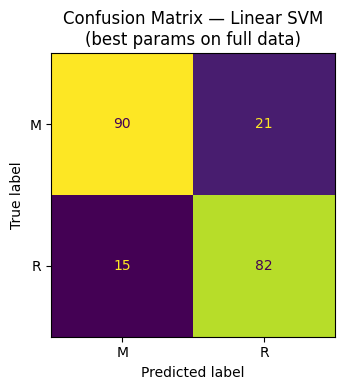

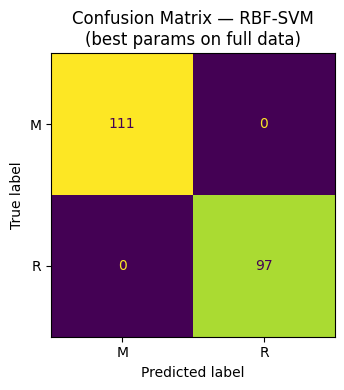

In [11]:
raw_df = show_results([result_lsvm, result_rbf])
plot_confusion_matrix("Linear SVM", pipeline_lsvm, param_grid_lsvm)
plot_confusion_matrix("RBF-SVM", pipeline_rbf, param_grid_rbf)

**Q3: Does RBF-SVM outperform Linear SVM? Why might this happen?**

是的，RBF-SVM 全面優於 Linear SVM：

| 指標 | Linear SVM | RBF-SVM |
|---|---|---|
| Accuracy | 0.7566 ± 0.0546 | 0.8460 ± 0.0638 |
| F1 | 0.7392 ± 0.0695 | 0.8293 ± 0.0727 |
| ROC-AUC | 0.8340 ± 0.0613 | 0.9344 ± 0.0410 |

原因有三：

**1. 資料非線性可分**
聲納訊號是 60 維的頻率反射強度，地雷與岩石在這個高維空間中的分佈邊界並非線性。Linear SVM 只能學一個超平面，結構上就無法完整描述這個邊界。

**2. RBF kernel 能捕捉非線性結構**
RBF kernel 透過 γ 控制每個訓練點的影響範圍，能在高維特徵空間中學習複雜的決策邊界，更適合這類聲納資料。

**3. 穩定性相近，非 overfit 造成的差距**
兩者 std 相近（0.0695 vs 0.0727），代表 RBF 的優勢來自於更好的模型能力，而非對特定 fold 過擬合。

▶ Running: MLP


,Model,accuracy,precision,recall,f1,roc_auc
0,Linear SVM,0.7566 ± 0.0546,0.7402 ± 0.0739,0.7496 ± 0.1078,0.7392 ± 0.0695,0.8340 ± 0.0613
1,MLP,0.7126 ± 0.1085,0.6936 ± 0.1143,0.7256 ± 0.0955,0.7048 ± 0.0941,0.7771 ± 0.1223
2,RBF-SVM,0.8460 ± 0.0638,0.8579 ± 0.0812,0.8098 ± 0.0969,0.8293 ± 0.0727,0.9344 ± 0.0410


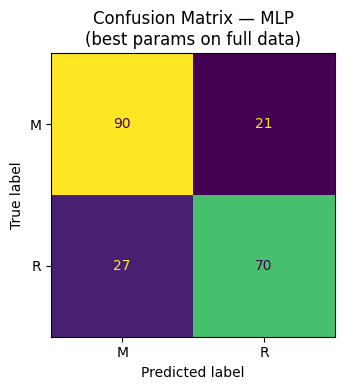

In [12]:
from sklearn.neural_network import MLPClassifier

pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        max_iter=3000,
        early_stopping=True,
        random_state=RANDOM_SEED,
    )),
])
param_grid_mlp = {
    "clf__hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "clf__alpha": [1e-4, 1e-3, 1e-2],
}

result_mlp = run_model("MLP", pipeline_mlp, param_grid_mlp)
show_results([result_lsvm, result_rbf, result_mlp])
plot_confusion_matrix("MLP", pipeline_mlp, param_grid_mlp)



---

**Q5: Does the MLP overfit or behave unstably?**

MLP 有明顯的不穩定問題：

| 指標 | MLP | RBF-SVM |
|---|---|---|
| Accuracy | 0.7126 ± **0.1085** | 0.8460 ± 0.0638 |
| F1 | 0.7048 ± **0.0941** | 0.8293 ± 0.0727 |
| ROC-AUC | 0.7771 ± **0.1223** | 0.9344 ± 0.0410 |

std 是所有模型中最高的，代表 MLP 在不同 fold 之間表現差異很大，行為不穩定。Confusion matrix 也顯示 MLP 對 R 的辨識特別差（27 個岩石被誤判為地雷），比 Linear SVM 還糟。

---

**Q6: Why might classical ML be more reliable than deep learning on this dataset?**

三個原因：

**1. 資料量太少（208筆）**
MLP 有大量參數需要學習，208 筆資料根本不夠讓它收斂到穩定的解。每次 CV fold 的訓練資料只有約 160 筆，MLP 很容易對這些資料過擬合。

**2. 特徵維度相對簡單（60維數值）**
聲納資料是結構化的數值特徵，不像圖片或文字需要深度學習來自動萃取特徵。RBF-SVM 這類 kernel 方法已經能有效捕捉非線性關係。

**3. 傳統 ML 樣本效率更高**
SVM 的最佳化目標是找最大 margin，在小資料集上有理論保證；MLP 靠梯度下降，小資料集上容易陷入局部最優或過擬合。

▶ Running: KNN


,Model,accuracy,precision,recall,f1,roc_auc
0,KNN,0.8098 ± 0.0783,0.8593 ± 0.0891,0.7076 ± 0.1404,0.7699 ± 0.1119,0.9046 ± 0.0506
1,Linear SVM,0.7566 ± 0.0546,0.7402 ± 0.0739,0.7496 ± 0.1078,0.7392 ± 0.0695,0.8340 ± 0.0613
2,MLP,0.7126 ± 0.1085,0.6936 ± 0.1143,0.7256 ± 0.0955,0.7048 ± 0.0941,0.7771 ± 0.1223
3,RBF-SVM,0.8460 ± 0.0638,0.8579 ± 0.0812,0.8098 ± 0.0969,0.8293 ± 0.0727,0.9344 ± 0.0410


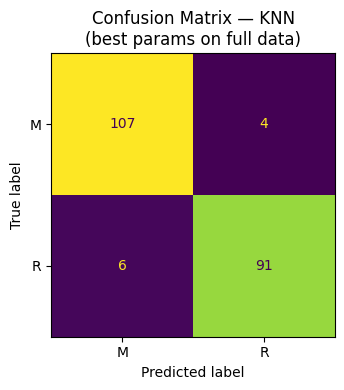

In [13]:
from sklearn.neighbors import KNeighborsClassifier

# Pipeline: StandardScaler → KNN
pipeline_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier()),
])
param_grid_knn = {"clf__n_neighbors": [3, 5, 7, 9]}

result_knn = run_model("KNN", pipeline_knn, param_grid_knn)
show_results([result_lsvm, result_rbf, result_mlp, result_knn])
plot_confusion_matrix("KNN", pipeline_knn, param_grid_knn)

**Q: How does KNN compare to the other models?**
| Model | Accuracy | F1 | ROC-AUC |
|---|---|---|---|
| RBF-SVM | 0.8460 ± 0.0638 | 0.8293 ± 0.0727 | 0.9344 ± 0.0410 |
| KNN | 0.8098 ± 0.0783 | 0.7699 ± 0.1119 | 0.9046 ± 0.0506 |
| Linear SVM | 0.7566 ± 0.0546 | 0.7392 ± 0.0695 | 0.8340 ± 0.0613 |
| MLP | 0.7126 ± 0.1085 | 0.7048 ± 0.0941 | 0.7771 ± 0.1223 |



▶ Running: XGBoost
▶ Running: Poly-SVM


,Model,accuracy,precision,recall,f1,roc_auc
0,KNN,0.8098 ± 0.0783,0.8593 ± 0.0891,0.7076 ± 0.1404,0.7699 ± 0.1119,0.9046 ± 0.0506
1,Linear SVM,0.7566 ± 0.0546,0.7402 ± 0.0739,0.7496 ± 0.1078,0.7392 ± 0.0695,0.8340 ± 0.0613
2,MLP,0.7126 ± 0.1085,0.6936 ± 0.1143,0.7256 ± 0.0955,0.7048 ± 0.0941,0.7771 ± 0.1223
3,Poly-SVM,0.8231 ± 0.0636,0.8406 ± 0.0772,0.7729 ± 0.1151,0.8001 ± 0.0787,0.9077 ± 0.0537
4,RBF-SVM,0.8460 ± 0.0638,0.8579 ± 0.0812,0.8098 ± 0.0969,0.8293 ± 0.0727,0.9344 ± 0.0410
5,XGBoost,0.8335 ± 0.0611,0.8457 ± 0.0701,0.7909 ± 0.1112,0.8129 ± 0.0755,0.9257 ± 0.0414


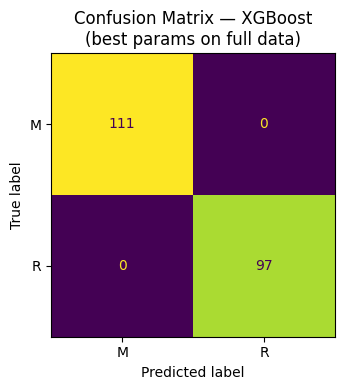

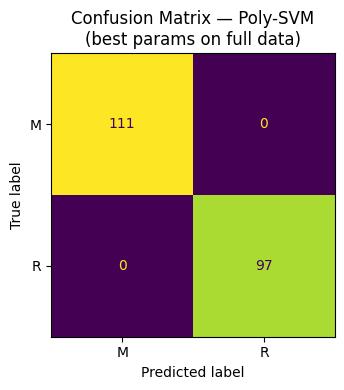

In [14]:
from xgboost import XGBClassifier

# XGBoost
pipeline_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_SEED,
        verbosity=0,
    )),
])
param_grid_xgb = {
    "clf__n_estimators": [50, 100],
    "clf__max_depth":    [2, 3],
    "clf__learning_rate": [0.05, 0.1],
}

# Poly-SVM
pipeline_poly = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="poly", probability=True, random_state=RANDOM_SEED)),
])
param_grid_poly = {
    "clf__C":      [0.1, 1, 10],
    "clf__degree": [2, 3],
    "clf__gamma":  ["scale", 0.01, 0.1],
    "clf__coef0":  [0, 1],
}

result_xgb  = run_model("XGBoost",  pipeline_xgb,  param_grid_xgb)
result_poly = run_model("Poly-SVM", pipeline_poly, param_grid_poly)

show_results([result_lsvm, result_rbf, result_mlp, result_knn, result_xgb, result_poly])
plot_confusion_matrix("XGBoost",  pipeline_xgb,  param_grid_xgb)
plot_confusion_matrix("Poly-SVM", pipeline_poly, param_grid_poly)

**Q: How do XGBoost and Poly-SVM compare to the other models?
|---|---|---|---|---|
| 1 | RBF-SVM | 0.8293 ± 0.0727 | 0.9344 ± 0.0410 | 0.8460 ± 0.0638 |
| 2 | XGBoost | 0.8129 ± 0.0755 | 0.9257 ± 0.0414 | 0.8335 ± 0.0611 |
| 3 | Poly-SVM | 0.8001 ± 0.0787 | 0.9077 ± 0.0537 | 0.8231 ± 0.0636 |
| 4 | KNN | 0.7699 ± 0.1119 | 0.9046 ± 0.0506 | 0.8098 ± 0.0783 |
| 5 | Linear SVM | 0.7392 ± 0.0695 | 0.8340 ± 0.0613 | 0.7566 ± 0.0546 |
| 6 | MLP | 0.7048 ± 0.0941 | 0.7771 ± 0.1223 | 0.7126 ± 0.1085 |
